# NLI Learner Corpus Builder

**Goal:** Build a filtered, normalized corpus of L2 English writing by speakers of a given L1, for Native Language Identification research.

**Parametric design:** change only `L1` and `SOURCES` in the config block to produce a corpus for any supported L1. All downstream code: alias matching, proficiency mapping, output filename adjusts automatically.

Implemented loaders: `pelic`. Stub loaders (implement when corpus is available): `corefl`, `icle`, `lang8`.

In [1]:
import os
import re
import json
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fasttext

# Suppress urllib3 / charset_normalizer noise (same pattern as lyrics pipeline)
warnings.filterwarnings("ignore")
fasttext.FastText.eprint = lambda *a, **k: None

print("Imports OK")

Imports OK


## Configuration

The **only block needed to change for different languages** to build a different L1 corpus. All paths, thresholds, and output filenames derive from these variables.

In [2]:
L1 = "spanish"              # change to: italian, dutch, russian, english, ...
SOURCES = ["pelic"]          # available: pelic. stubs: corefl, icle, lang8

MIN_TEXT_LENGTH   = 50       # min tokens (whitespace split); shorter texts dropped
MAX_TEXT_LENGTH   = 1000     # cap; longer texts truncated, not dropped
MIN_ENGLISH_RATIO = 0.95     # fastText line-level threshold, same as lyrics pipeline
RANDOM_STATE = 42

OUTPUT_PATH = f"data/{L1}/processed/learner_corpus_{L1}.csv" 

# fastText LID model already downloaded by the lyrics pipeline
FASTTEXT_MODEL_PATH = Path("data/spanish/lid.176.ftz")

# Corpus file paths (adjust if you move them)
PELIC_PATH = Path("vendor/PELIC-dataset/PELIC_compiled.csv")

print(f"L1: {L1} | Sources: {SOURCES}")
print(f"Filters: min_tokens={MIN_TEXT_LENGTH}, max_tokens={MAX_TEXT_LENGTH}, "
      f"min_english_ratio={MIN_ENGLISH_RATIO}")

L1: spanish | Sources: ['pelic']
Filters: min_tokens=50, max_tokens=1000, min_english_ratio=0.95


## L1 normalization and loader contract

### Why an alias map?

Each corpus encodes L1 differently (`"Spanish"`, `"spanish"`, `"es"`, `"Spa"`, …). A central alias map lets every loader normalize to a single lowercase key without corpus-specific branching.

### Loader interface contract

Every loader must have the signature `(path: str | Path, l1: str) -> pd.DataFrame` and return a DataFrame with exactly these columns:

| Column | Type | Notes |
|--------|------|-------|
| `text_id` | str | Prefixed: `"pelic_19399"`, `"corefl_S023_T04"`, … |
| `L1` | str | Lowercase: `"spanish"`, `"italian"`, … |
| `source` | str | `"pelic"`, `"corefl"`, `"icle"`, `"lang8"` |
| `text` | str | Cleaned English text |
| `n_tokens` | int | `len(text.split())` — whitespace split, consistent with lyrics pipeline |
| `proficiency` | str \| None | CEFR label if available, else `None` |
| `metadata_json` | str | JSON string with source-specific extras |

To add a new corpus (e.g. EFCAMDAT), implement `load_efcamdat(path, l1)` following this contract, add its L1 surface forms to `L1_ALIASES`, register it in `LOADER_REGISTRY`, and append `"efcamdat"` to `SOURCES`.

In [3]:
L1_ALIASES: dict[str, list[str]] = {
    "spanish":  ["Spanish", "spanish", "es", "ES", "Spa"],
    "italian":  ["Italian", "italian", "it", "IT", "Ita"],
    "dutch":    ["Dutch",   "dutch",   "nl", "NL", "Dut"],
    "russian":  ["Russian", "russian", "ru", "RU", "Rus"],
    "english":  ["English", "english", "en", "EN", "Eng"],
    "arabic":   ["Arabic",  "arabic",  "ar", "AR", "Ara"],
    "chinese":  ["Chinese", "chinese", "zh", "ZH", "Chi", "Mandarin"],
    "japanese": ["Japanese","japanese","ja", "JA", "Jpn"],
    "korean":   ["Korean",  "korean",  "ko", "KO", "Kor"],
    "turkish":  ["Turkish", "turkish", "tr", "TR", "Tur"],
    "french":   ["French",  "french",  "fr", "FR", "Fre"],
    "german":   ["German",  "german",  "de", "DE", "Ger"],
}

# PELIC levels 2-5 mapped to CEFR per the PELIC README
PELIC_LEVEL_TO_CEFR: dict[int, str] = {
    2: "A2",
    3: "B1",
    4: "B1+/B2",
    5: "B2+/C1",
}


def get_l1_aliases(l1: str) -> list[str]:
    """Return all known surface forms for a canonical L1 label."""
    return L1_ALIASES.get(l1.lower(), [l1])

## Loaders

### PELIC

[PELIC](https://github.com/eli-data-mining-group/Pitt-ELI-Corpus) is the University of Pittsburgh English Language Institute Corpus: ~46 k texts from an EAP writing program, with L1, gender, course level, and NLTK token annotations. We use the pre-compiled `PELIC_compiled.csv`.

**Note on token counting:** PELIC ships a `text_len` column computed with NLTK tokenization (punctuation split from words). We recount with `len(text.split())` for consistency with the lyrics pipeline, and archive the original NLTK count in `metadata_json`.

In [4]:
def load_pelic(path: str | Path, l1: str) -> pd.DataFrame:
    """Load PELIC_compiled.csv and return texts matching the requested L1.

    Args:
        path: Path to PELIC_compiled.csv.
        l1:   Canonical L1 label (e.g. "spanish").

    Returns:
        DataFrame conforming to the loader interface contract.

    Raises:
        FileNotFoundError: if path does not exist.
        ValueError: if no rows match the requested L1.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path, dtype=str)

    aliases = get_l1_aliases(l1)
    df = df[df["L1"].isin(aliases)].copy()
    if df.empty:
        raise ValueError(
            f"No PELIC rows found for L1={l1!r} (tried aliases: {aliases}). "
            f"Available L1s: {sorted(pd.read_csv(path, usecols=['L1'])['L1'].unique())}"
        )

    rows = []
    for _, row in df.iterrows():
        text = str(row["text"]).strip()
        level_id = int(row["level_id"]) if str(row["level_id"]).isdigit() else None
        rows.append({
            "text_id":       f"pelic_{row['answer_id']}",
            "L1":            l1.lower(),
            "source":        "pelic",
            "text":          text,
            "n_tokens":      len(text.split()),
            "proficiency":   PELIC_LEVEL_TO_CEFR.get(level_id),
            "metadata_json": json.dumps({
                "anon_id":      row["anon_id"],
                "gender":       row["gender"],
                "level_id":     row["level_id"],
                "course_id":    row["course_id"],
                "version":      row["version"],
                "text_len_nltk": row["text_len"],
            }),
        })
    return pd.DataFrame(rows)

### Stub loaders

The loaders below have the correct signature but are not implemented. Replace the `raise NotImplementedError` body with real parsing logic when the corpus is available. Each docstring documents where to obtain the corpus and what format to expect.

In [5]:
def load_corefl(path: str | Path, l1: str) -> pd.DataFrame:
    """Stub: Corpus of English as a Foreign Language (COREFL).

    COREFL contains Spanish and Italian L1 texts from Dutch secondary schools.
    Expected format: XML files organized by L1 subdirectory, or a compiled CSV
    depending on the release version.

    To obtain: contact the COREFL authors or check
    https://cls.ru.nl/staff/scheepers/ for access instructions.
    Place files in vendor/COREFL/.

    Raises:
        NotImplementedError: until this loader is implemented.
    """
    raise NotImplementedError(
        "load_corefl is not implemented. "
        "Obtain COREFL from the project authors and implement parsing here. "
        "See docstring for format details."
    )


def load_icle(path: str | Path, l1: str) -> pd.DataFrame:
    """Stub: International Corpus of Learner English (ICLE).

    ICLE contains argumentative essays from advanced EFL learners across 16 L1s
    (Spanish, Italian, Dutch, Russian, and others). Format: plain-text files in
    L1-organized subdirectories, one file per essay.

    To obtain: AUC may have institutional access via ILR or CECL.
    Contact learner-corpus@uclouvain.ac.be or check with the AUC library.
    Place files in vendor/ICLE/.

    Raises:
        NotImplementedError: until this loader is implemented.
    """
    raise NotImplementedError(
        "load_icle is not implemented. "
        "ICLE requires a license; check AUC library access or contact CECL. "
        "See docstring for format details."
    )


def load_lang8(path: str | Path, l1: str) -> pd.DataFrame:
    """Stub: Lang-8 learner corpus.

    *** IMPORTANT: there are two distinct Lang-8 releases ***

    1. lang-8-en-1.0 (Tajiri et al., ACL 2012) — a verb-phrase correction corpus
       with ~100k English sentences and their edits. This version has NO native-
       language metadata and CANNOT be used for NLI. Do not use this release.

    2. The full multilingual dump (Mizumoto et al., IJCNLP 2011) — includes
       user-level native_language fields alongside journal entries. This is the
       correct version. Expected columns: user_id, native_language,
       learning_language, body.

    To obtain release (2): email komachi@is.naist.jp requesting the full dataset
    with user metadata. A data-use agreement is required.
    Place files in vendor/lang8/.

    Raises:
        NotImplementedError: until this loader is implemented.
    """
    raise NotImplementedError(
        "load_lang8 is not implemented. "
        "You need the FULL Lang-8 dataset (Mizumoto et al., 2011), not lang-8-en-1.0. "
        "Email komachi@is.naist.jp for the user-metadata version. "
        "See docstring for critical version distinction."
    )


# Dispatcher: maps source name → (loader_fn, default_path)
LOADER_REGISTRY: dict[str, tuple] = {
    "pelic":  (load_pelic,  PELIC_PATH),
    "corefl": (load_corefl, Path("vendor/COREFL/")),
    "icle":   (load_icle,   Path("vendor/ICLE/")),
    "lang8":  (load_lang8,  Path("vendor/lang8/")),
}

## Load and combine sources

Stubs and missing files emit a warning and are skipped rather than crashing — the pipeline runs end-to-end with whatever sources are available.

In [6]:
frames: list[pd.DataFrame] = []
load_log: dict[str, int] = {}

for source in SOURCES:
    if source not in LOADER_REGISTRY:
        print(f"\u26a0\ufe0f  Unknown source '{source}', not in LOADER_REGISTRY. Skipping.")
        continue

    loader_fn, default_path = LOADER_REGISTRY[source]
    try:
        df_src = loader_fn(default_path, L1)
        frames.append(df_src)
        load_log[source] = len(df_src)
        print(f"\u2713  {source}: {len(df_src):,} texts loaded")
    except NotImplementedError as e:
        print(f"\u26a0\ufe0f  {source}: stub not implemented — {e}")
        load_log[source] = 0
    except FileNotFoundError:
        print(f"\u26a0\ufe0f  {source}: corpus file not found at {default_path}")
        print(f"    \u2192 Place corpus files in vendor/{source.upper()}/ and implement the loader.")
        load_log[source] = 0
    except Exception as e:
        print(f"\u26a0\ufe0f  {source}: unexpected error — {e}")
        load_log[source] = 0

if not frames:
    raise RuntimeError("No sources loaded successfully. Check SOURCES and corpus paths.")

corpus = pd.concat(frames, ignore_index=True)
print(f"\n{'='*50}")
print(f"Raw corpus: {len(corpus):,} texts from {len(frames)} source(s)")
print(f"{'='*50}")

✓  pelic: 1,909 texts loaded

Raw corpus: 1,909 texts from 1 source(s)


## Quality filters

Applied in order after loading, source-agnostic:

1. **Length floor**: drop texts shorter than `MIN_TEXT_LENGTH` tokens. Short exercise responses (single sentences, one-word answers) are too thin for NLI feature extraction.
2. **Length ceiling**: *truncate* texts longer than `MAX_TEXT_LENGTH` tokens. Prevents any one prolific student from dominating the corpus by word volume; truncation preserves the L1 signal rather than discarding the text entirely.
3. **Language ID**: fastText line-level classification (lid.176, consistent with lyrics pipeline). Learner texts occasionally include native-language asides. We drop texts below the English-ratio threshold.
4. **Deduplication**: drop exact-duplicate texts. PELIC records multiple submission versions for some students; we keep the first occurrence.

In [7]:
# Load fastText model (already downloaded by lyrics pipeline; no re-download)
assert FASTTEXT_MODEL_PATH.exists(), (
    f"fastText model not found at {FASTTEXT_MODEL_PATH}. "
    "Run build_lyrics_corpus_spanish.ipynb first, or download "
    "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz"
)
ft_model = fasttext.load_model(str(FASTTEXT_MODEL_PATH))
print(f"fastText model loaded from {FASTTEXT_MODEL_PATH}")


def compute_english_ratio(text: str) -> float:
    """Line-level fastText English ratio, consistent with lyrics pipeline."""
    lines = [
        ln.strip()
        for ln in re.split(r"[\n.!?]", text)
        if ln.strip() and len(ln.strip()) > 3
    ]
    if not lines:
        return 0.0
    labels, _ = ft_model.predict(lines, k=1)
    return sum(1 for lbl in labels if lbl[0] == "__label__en") / len(lines)


def truncate_tokens(text: str, max_tokens: int) -> str:
    """Return first max_tokens whitespace-split tokens."""
    tokens = text.split()
    return " ".join(tokens[:max_tokens]) if len(tokens) > max_tokens else text


# ── Filter pipeline
stage_counts: dict[str, int] = {"0_raw": len(corpus)}

# 1. Length floor
corpus = corpus[corpus["n_tokens"] >= MIN_TEXT_LENGTH].copy()
stage_counts["1_min_length"] = len(corpus)

# 2. Length ceiling — truncate, not drop
n_truncated = (corpus["n_tokens"] > MAX_TEXT_LENGTH).sum()
corpus["text"]    = corpus["text"].apply(lambda t: truncate_tokens(t, MAX_TEXT_LENGTH))
corpus["n_tokens"] = corpus["text"].apply(lambda t: len(t.split()))
stage_counts["2_truncated"] = len(corpus)

# 3. English ratio
print("Computing fastText English ratios...")
corpus["english_ratio"] = corpus["text"].apply(compute_english_ratio)
corpus = corpus[corpus["english_ratio"] >= MIN_ENGLISH_RATIO].copy()
stage_counts["3_english_filter"] = len(corpus)

# 4. Deduplication
corpus = corpus.drop_duplicates(subset=["text"]).reset_index(drop=True)
stage_counts["4_dedup"] = len(corpus)

# ── Dropoff summary
labels_map = {
    "0_raw":            "Raw loaded",
    "1_min_length":     f"After min_tokens\u2265{MIN_TEXT_LENGTH}",
    "2_truncated":      f"After truncation (\u2264{MAX_TEXT_LENGTH})  [{n_truncated} texts truncated]",
    "3_english_filter": f"After english_ratio\u2265{MIN_ENGLISH_RATIO}",
    "4_dedup":          "After deduplication",
}
print(f"\n{'='*60}")
print(f"FILTER DROPOFF \u2014 L1: {L1}")
print(f"{'='*60}")
prev = None
for key, label in labels_map.items():
    n = stage_counts[key]
    dropped = f"  (\u2212{prev - n})" if prev is not None and key != "2_truncated" else ""
    print(f"  {label:<58} {n:>5}{dropped}")
    prev = n
print(f"{'='*60}")
print(f"\nPer-source breakdown (final):")
print(corpus.groupby("source").size().to_string())

fastText model loaded from data/spanish/lid.176.ftz
Computing fastText English ratios...

FILTER DROPOFF — L1: spanish
  Raw loaded                                                  1909
  After min_tokens≥50                                          822  (−1087)
  After truncation (≤1000)  [3 texts truncated]                822
  After english_ratio≥0.95                                     768  (−54)
  After deduplication                                          755  (−13)

Per-source breakdown (final):
source
pelic    755


## Export

Write the final filtered corpus to `OUTPUT_PATH`. The schema is shared across all L1s so downstream classifiers can load any teammate's output without modification.

In [8]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

output_cols = ["text_id", "L1", "source", "text", "n_tokens",
               "proficiency", "english_ratio", "metadata_json"]
corpus[output_cols].to_csv(OUTPUT_PATH, index=False)

print(f"Saved {len(corpus):,} texts \u2192 {OUTPUT_PATH.resolve()}")
print(f"File size: {OUTPUT_PATH.stat().st_size / 1024:.1f} KB")

Saved 755 texts → /Users/nataliajimenez/Desktop/AUC/TM/project/data/learner_corpus_spanish.csv
File size: 1009.0 KB


## EDA

Sanity-check the final corpus before handing off to classifiers.

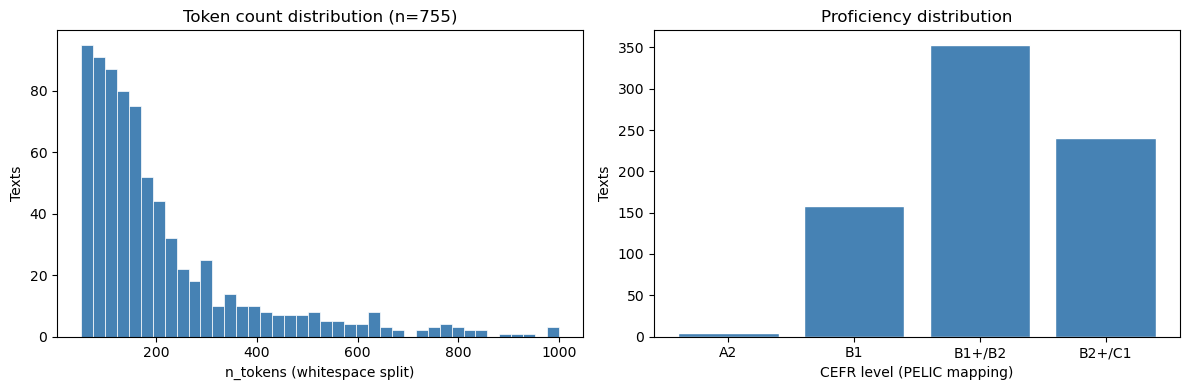

Token count stats (final corpus):
count     755.0
mean      210.1
std       171.4
min        50.0
25%        98.0
50%       151.0
75%       248.5
max      1000.0

Proficiency breakdown:
proficiency
A2          4
B1        158
B1+/B2    353
B2+/C1    240

Total texts: 755

5 RANDOM SAMPLE TEXTS

[1] pelic_34037 | proficiency=B2+/C1 | n_tokens=779 | english_ratio=0.96
Friday, 2-26-2010
Writing 5S
Comparison Essay
Alejandra Parra

Pancakes, Eggs or Yogurt

Pancakes, eggs, or yogurt, these are the types of choices that my mother has to confront early in the morning each day. My brothers and I are physically very alike, but our personalities couldn't differ more. Fo…

[2] pelic_21001 | proficiency=B1 | n_tokens=116 | english_ratio=1.00
VACATION IN SPACE

Enjoy of their better vacations in the space with you family. You will find Hotels in orbit, this will offer the services you expect from a hotel, private rooms, private bathroom, television meals and bars for dance with low gravity, they'l

In [9]:
rng = np.random.default_rng(RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Token count distribution
axes[0].hist(corpus["n_tokens"], bins=40, color="steelblue",
             edgecolor="white", linewidth=0.5)
axes[0].set_title(f"Token count distribution (n={len(corpus)})")
axes[0].set_xlabel("n_tokens (whitespace split)")
axes[0].set_ylabel("Texts")

# Proficiency distribution
prof_counts = corpus["proficiency"].fillna("Unknown").value_counts()
cefr_order  = [c for c in ["A2", "B1", "B1+/B2", "B2+/C1", "Unknown"]
               if c in prof_counts.index]
axes[1].bar(cefr_order, [prof_counts[c] for c in cefr_order],
            color="steelblue", edgecolor="white")
axes[1].set_title("Proficiency distribution")
axes[1].set_xlabel("CEFR level (PELIC mapping)")
axes[1].set_ylabel("Texts")

plt.tight_layout()
plt.show()

# Summary stats
print("Token count stats (final corpus):")
print(corpus["n_tokens"].describe().round(1).to_string())
print("\nProficiency breakdown:")
print(corpus["proficiency"].fillna("Unknown").value_counts().sort_index().to_string())
print(f"\nTotal texts: {len(corpus)}")

# 5 random samples
print("\n" + "="*60)
print("5 RANDOM SAMPLE TEXTS")
print("="*60)
sample_idx = rng.choice(len(corpus), size=min(5, len(corpus)), replace=False)
for i, idx in enumerate(sample_idx, 1):
    row = corpus.iloc[idx]
    preview = row["text"][:300] + ("\u2026" if len(row["text"]) > 300 else "")
    print(f"\n[{i}] {row['text_id']} | proficiency={row['proficiency']} | "
          f"n_tokens={row['n_tokens']} | english_ratio={row['english_ratio']:.2f}")
    print(preview)

## Notes for other languages

### What's implemented vs. stub

| Source | Status | Notes |
|--------|--------|-------|
| PELIC  | ✅ Implemented | `vendor/PELIC-dataset/PELIC_compiled.csv` |
| COREFL | 🔲 Stub | Contact COREFL authors; see `load_corefl` docstring |
| ICLE   | 🔲 Stub | AUC institutional access; see `load_icle` docstring |
| Lang-8 | 🔲 Stub | Requires full metadata release — **do not use `lang-8-en-1.0`** |

### Switching to your L1

Change only `L1` in the config block and re-run all cells:

```python
L1 = "italian"   # or: dutch, russian, english, arabic, ...
```

**Important — PELIC coverage by L1:**

| L1 | PELIC texts |
|---------|-------------|
| Arabic | 16,831 |
| Korean | 9,208 |
| Chinese | 8,503 |
| Japanese | 2,782 |
| Spanish | 1,909 |
| Turkish | 1,537 |
| Italian | 393 |
| Russian | 193 |
| Dutch | 0 |

If your L1 is **Italian** or **Russian**, PELIC has few texts. Implement `load_corefl()` or `load_icle()` first and add the source to `SOURCES`.
If your L1 is **Dutch**, PELIC has no texts, you will need COREFL or ICLE.

### Adding a new corpus

1. Place corpus files in `vendor/<CORPUS_NAME>/`
2. Implement `load_<corpus>(path, l1) -> pd.DataFrame` following the interface contract above
3. Add new L1 surface forms to `L1_ALIASES` if needed
4. Register in `LOADER_REGISTRY`
5. Append `"<corpus>"` to `SOURCES` in the config block

### Output schema (shared across all L1s)

```
text_id, L1, source, text, n_tokens, proficiency, english_ratio, metadata_json
```

Downstream classifiers should read from `data/learner_corpus_<L1>.csv` and can concatenate multiple L1 files without schema conflicts.